# 10장: GBM과 Random Forest 모델링 (수정판)

이 노트북은 기존 10번 노트북에서 오래 걸리던 원인들을 수정한 버전입니다.

**수정 사항 (9장 수정판과 동일한 원칙)**
1. **어근추출·TF-IDF를 처음부터 다시 하지 않습니다.** 9장에서 이미 저장해둔 `tfidf_lemmatized_fixed.npz`와 `X_final.pkl`을 그대로 불러와 재사용합니다 — 어근추출(약 10분)과 TF-IDF 재적합 과정을 통째로 건너뛰어 가장 큰 시간을 절약합니다.
2. **`.toarray()`로 dense 변환하지 않습니다.** 기존 코드는 `X_train_dense = X_train.toarray()`로 50,000+ 컬럼짜리 sparse 행렬을 전부 dense로 바꿨는데, 이게 메모리도 크게 잡아먹고 이후 모델 학습을 극도로 느리게 만드는 핵심 원인이었습니다. sparse 상태 그대로 모델에 넣습니다.
3. **`GradientBoostingRegressor` → `HistGradientBoostingRegressor`로 교체합니다.** 기존 `GradientBoostingRegressor`는 sparse 입력을 지원하지 않아 dense 변환이 강제됐던 것인데, `HistGradientBoostingRegressor`는 sparse를 직접 지원하고 구조적으로 훨씬 빠릅니다.
4. **`RandomForestRegressor`도 sparse를 그대로 입력**합니다 (원래 sparse 입력을 지원하는데 기존 코드가 불필요하게 dense로 바꿨습니다).
5. **Optuna 튜닝을 제거**하고 고정 하이퍼파라미터로 바로 학습합니다 (9장에서 LightGBM·XGBoost에 적용한 것과 동일한 방식). GBM·RF 모두 트리 개수와 깊이를 무겁게 탐색하는 Optuna 튜닝이 대용량 데이터에서 가장 느린 구간이었습니다.
6. **9장 결과 파일 경로를 실제 저장된 파일명(`_fixed` 접미사)으로 맞춥니다.** 기존 코드는 `lemmatization_results.csv`를 찾는데, 9장 수정판은 `lemmatization_results_fixed.csv`로 저장하므로 경로가 어긋나 있었습니다.
7. **sklearn 버전을 짐작하지 않고, 실제 시도 후 예외로 판단합니다.** `HistGradientBoostingRegressor`의 sparse 지원 여부는 sklearn 버전마다 다른데, 버전 문자열로 미리 판단하는 방식은 실제 환경에서 빗나갈 수 있습니다. 그래서 sparse로 먼저 학습을 시도하고, 그 시점에 나는 `TypeError`를 직접 잡아서 필요할 때만 TruncatedSVD로 300차원 압축 후 재시도하도록 바꿨습니다.
8. **9장과의 연결 지점을 보강합니다.** (1) 9장 결과물을 불러온 직후 행 개수가 서로 일치하는지 정합성 검증을 추가했고, (2) 9장의 11.5단계와 동일한 패턴으로 GBM·Random Forest 결과에도 재시작 안전장치(6.5단계)를 추가했고, (3) 9장 결과 CSV에서 모델을 못 찾을 경우 어떤 모델명이 실제로 있는지 알려주도록 오류 메시지를 구체화했습니다.

**실행 전 확인해주세요**
- 9장 수정판(`09_Lemmatization_Fixed.ipynb`)을 먼저 끝까지 실행해서 `tfidf_lemmatized_fixed.npz`, `X_final.pkl`, `y_log.pkl`, `lemmatization_results_fixed.csv` 파일이 만들어져 있어야 합니다.
- 경로가 다르면 데이터 로드 셀의 경로만 조정해주세요.

## 1단계: 라이브러리 임포트

In [1]:
import multiprocessing
import numpy as np
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.decomposition import TruncatedSVD
import joblib
from scipy.sparse import hstack, csr_matrix, load_npz
import warnings
warnings.filterwarnings('ignore')

N_THREADS = multiprocessing.cpu_count()
print(f"scikit-learn 버전: {sklearn.__version__}")
print(f"모든 라이브러리 임포트 완료! (사용 가능 코어: {N_THREADS}개)")

scikit-learn 버전: 1.9.0
모든 라이브러리 임포트 완료! (사용 가능 코어: 12개)


## 2단계: 9장에서 저장한 결과 재사용 (어근추출·TF-IDF 재실행 없음)

9장 수정판에서 이미 만들어둔 TF-IDF(어근추출 반영) 결과와, 유의변수만 추린 `X_final`(297컬럼)을 그대로 불러옵니다. 어근추출(약 10분)과 TF-IDF 재적합을 다시 하지 않는 것만으로도 상당한 시간이 절약됩니다.

**보강**: 파일을 불러온 직후 행(row) 개수가 서로 일치하는지 확인하는 정합성 검증을 추가했습니다. 9장을 일부만 실행했거나 다른 버전의 파일이 섞여 있으면 이 단계에서 바로 걸러집니다.

In [2]:
print("9장에서 저장한 TF-IDF·정형 피처 로드 중...")

try:
    tfidf_lemmatized = load_npz("../data/processed/tfidf_lemmatized_fixed.npz")
except FileNotFoundError:
    raise FileNotFoundError(
        "tfidf_lemmatized_fixed.npz를 찾을 수 없습니다. "
        "09_Lemmatization_Fixed.ipynb의 6단계까지 먼저 실행해서 이 파일을 생성해주세요."
    )
print(f"TF-IDF shape: {tfidf_lemmatized.shape}")

X_final = pd.read_pickle("../data/processed/X_final.pkl")

# 혹시 모를 타겟 누수 컬럼(price, log_price 등) 안전 점검
leak_cols = [col for col in X_final.columns if 'price' in col.lower()]
if leak_cols:
    print(f"타겟 누수 의심 컬럼 제거: {leak_cols}")
    X_final = X_final.drop(columns=leak_cols)

X_final_sparse = csr_matrix(X_final.values.astype(np.float32))
print(f"정형 피처 shape: {X_final_sparse.shape}")

y_log = pd.read_pickle("../data/processed/y_log.pkl")

# 정합성 검증: 세 데이터의 행(row) 개수가 서로 일치해야 정상적으로 연결된 것
n_tfidf, n_final, n_y = tfidf_lemmatized.shape[0], X_final_sparse.shape[0], y_log.shape[0]
if not (n_tfidf == n_final == n_y):
    raise ValueError(
        f"9장 결과물의 행 개수가 서로 일치하지 않습니다 "
        f"(tfidf={n_tfidf}, X_final={n_final}, y_log={n_y}). "
        "9장을 처음부터 다시 실행했거나 파일이 갱신됐는지 확인해주세요."
    )

print(f"정합성 검증 통과 (행 개수 일치: {n_tfidf:,}개)")
print("로드 완료")

9장에서 저장한 TF-IDF·정형 피처 로드 중...
TF-IDF shape: (1481611, 50000)
정형 피처 shape: (1481611, 297)
정합성 검증 통과 (행 개수 일치: 1,481,611개)
로드 완료


## 3단계: 데이터 결합 및 분할 (sparse 유지)

In [3]:
print("정형 피처와 텍스트 피처 결합 중...")
X_combined = hstack([X_final_sparse, tfidf_lemmatized]).tocsr()
print(f"결합된 특성 행렬 shape: {X_combined.shape}")

del X_final_sparse, tfidf_lemmatized
import gc
gc.collect()

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X_combined, y_log, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

del X_combined
gc.collect()

# 수정: .toarray() 삭제 - GBM/RF 모두 sparse 그대로 사용

정형 피처와 텍스트 피처 결합 중...
결합된 특성 행렬 shape: (1481611, 50297)
X_train shape: (1185288, 50297)
X_test shape: (296323, 50297)


0

## 4단계: 평가 함수 정의

In [4]:
def rmsle(y_true, y_pred):
    """RMSLE 계산"""
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))

y_test_orig = np.expm1(y_test_log.values)
print("RMSLE 함수 정의 완료")

RMSLE 함수 정의 완료


## 5단계: Gradient Boosting - 고정 하이퍼파라미터로 학습 (Optuna 미사용)

**수정**: `GradientBoostingRegressor`(sparse 미지원) 대신 **`HistGradientBoostingRegressor`**를 사용합니다. scikit-learn 버전에 따라 sparse 입력 지원 여부가 다른데, 버전 문자열로 미리 짐작하는 대신 **sparse로 실제 학습을 먼저 시도하고, 그 시점에 나는 에러를 직접 잡아서** 필요할 때만 TruncatedSVD로 300차원까지 압축한 뒤 dense로 재시도하는 방식으로 처리합니다. 이렇게 하면 설치된 버전이 정확히 무엇이든 상관없이 항상 동작합니다.

In [5]:
def _build_gbm():
    return HistGradientBoostingRegressor(
        max_iter=300,
        max_depth=8,
        learning_rate=0.08,
        l2_regularization=0.1,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15,
        random_state=42,
    )

print("Gradient Boosting 학습 중 (고정 파라미터, HistGradientBoosting)...")

try:
    gbm_model = _build_gbm()
    gbm_model.fit(X_train, y_train_log.values)
    X_test_gbm = X_test
    print("sparse 입력으로 학습 성공")
except TypeError as e:
    if "sparse" not in str(e).lower():
        raise
    print("현재 scikit-learn 버전은 sparse 입력을 지원하지 않습니다.")
    print("TruncatedSVD로 300차원 압축 후 재시도합니다...")
    svd_gbm = TruncatedSVD(n_components=300, random_state=42)
    X_train_gbm = svd_gbm.fit_transform(X_train)
    X_test_gbm = svd_gbm.transform(X_test)
    gbm_model = _build_gbm()
    gbm_model.fit(X_train_gbm, y_train_log.values)

gbm_pred_log = gbm_model.predict(X_test_gbm)
gbm_pred = np.clip(np.expm1(gbm_pred_log), 0, None)
gbm_rmsle = rmsle(y_test_orig, gbm_pred)

print(f"GBM 최종 RMSLE: {gbm_rmsle:.6f}")
print(f"실제 사용된 트리 수: {gbm_model.n_iter_} (early stopping 적용)")

joblib.dump(gbm_model, "../data/processed/gbm_lemmatized_model_fixed.pkl")
print("GBM 모델 저장 완료")

Gradient Boosting 학습 중 (고정 파라미터, HistGradientBoosting)...
현재 scikit-learn 버전은 sparse 입력을 지원하지 않습니다.
TruncatedSVD로 300차원 압축 후 재시도합니다...
GBM 최종 RMSLE: 0.551998
실제 사용된 트리 수: 300 (early stopping 적용)
GBM 모델 저장 완료


## 6단계: Random Forest - 고정 하이퍼파라미터로 학습 (Optuna 미사용)

**수정**: `.toarray()` 없이 sparse 행렬을 그대로 사용합니다 (RandomForestRegressor는 원래 sparse 입력을 지원합니다). `n_jobs=-1`로 가용 코어를 모두 사용하고, `n_estimators`와 `max_depth`를 무겁지 않은 값으로 고정해 학습 시간을 단축합니다.

In [6]:
print("Random Forest 학습 중 (고정 파라미터)...")

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=3,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
)
rf_model.fit(X_train, y_train_log.values)

rf_pred_log = rf_model.predict(X_test)
rf_pred = np.clip(np.expm1(rf_pred_log), 0, None)
rf_rmsle = rmsle(y_test_orig, rf_pred)

print(f"Random Forest 최종 RMSLE: {rf_rmsle:.6f}")

joblib.dump(rf_model, "../data/processed/randomforest_lemmatized_model_fixed.pkl")
print("Random Forest 모델 저장 완료")

Random Forest 학습 중 (고정 파라미터)...
Random Forest 최종 RMSLE: 0.695365
Random Forest 모델 저장 완료


## 6.5단계: 결과 안전장치 (커널 재시작 대비)

9장의 11.5단계와 동일한 원칙입니다. `gbm_rmsle`, `rf_rmsle`가 이 세션에서 이미 계산되어 있으면 그대로 쓰고, 커널을 재시작해서 메모리에 없으면 저장된 모델 파일을 불러와 다시 계산합니다.

In [7]:
if 'X_test' not in globals():
    raise RuntimeError(
        "X_train / X_test가 없습니다. 먼저 2~3단계(9장 결과 로드, 데이터 결합·분할)를 실행한 뒤 이 셀을 다시 실행하세요."
    )

if 'gbm_rmsle' not in globals():
    print("GBM 결과가 메모리에 없어 저장된 모델을 불러옵니다...")
    gbm_model = joblib.load("../data/processed/gbm_lemmatized_model_fixed.pkl")
    # 모델이 학습될 때 입력받은 차원 수(n_features_in_)로 원본 sparse(X_test)를 그대로 쓸지,
    # TruncatedSVD로 300차원 압축한 버전을 써야 할지 판단합니다 (버전 추측 대신 실제 모델 기준).
    if gbm_model.n_features_in_ == X_test.shape[1]:
        X_test_gbm_reload = X_test
    else:
        # 학습 당시와 동일한 random_state로 재적합하면 TruncatedSVD는 결정적으로 동일하게 재현됩니다.
        svd_gbm = TruncatedSVD(n_components=gbm_model.n_features_in_, random_state=42)
        svd_gbm.fit(X_train)
        X_test_gbm_reload = svd_gbm.transform(X_test)
    gbm_pred_log = gbm_model.predict(X_test_gbm_reload)
    gbm_pred = np.clip(np.expm1(gbm_pred_log), 0, None)
    gbm_rmsle = rmsle(y_test_orig, gbm_pred)
    print(f"GBM RMSLE (불러온 모델로 재계산): {gbm_rmsle:.6f}")
else:
    print(f"GBM RMSLE (메모리에 있는 값 사용): {gbm_rmsle:.6f}")

if 'rf_rmsle' not in globals():
    print("Random Forest 결과가 메모리에 없어 저장된 모델을 불러옵니다...")
    rf_model = joblib.load("../data/processed/randomforest_lemmatized_model_fixed.pkl")
    rf_pred_log = rf_model.predict(X_test)
    rf_pred = np.clip(np.expm1(rf_pred_log), 0, None)
    rf_rmsle = rmsle(y_test_orig, rf_pred)
    print(f"Random Forest RMSLE (불러온 모델로 재계산): {rf_rmsle:.6f}")
else:
    print(f"Random Forest RMSLE (메모리에 있는 값 사용): {rf_rmsle:.6f}")

print("\nGBM·Random Forest 결과 준비 완료 — 7단계로 진행하세요.")

GBM RMSLE (메모리에 있는 값 사용): 0.551998
Random Forest RMSLE (메모리에 있는 값 사용): 0.695365

GBM·Random Forest 결과 준비 완료 — 7단계로 진행하세요.


## 7단계: 9장 결과 로드

**수정**: 9장 수정판이 실제로 저장하는 파일명(`lemmatization_results_fixed.csv`, 모델명 `Ridge (어근추출)` 등)에 맞춰 경로와 모델명을 수정했습니다.

In [8]:
print("9장 모델 결과 로드...")

EXPECTED_MODELS = ['Ridge (Optuna 튜닝)', 'LightGBM (고정 파라미터)', 'XGBoost (고정 파라미터)']
ridge_rmsle = lgb_rmsle = xgb_rmsle = None

try:
    previous_results = pd.read_csv("../data/processed/lemmatization_results_fixed.csv")
except FileNotFoundError:
    print("lemmatization_results_fixed.csv를 찾을 수 없습니다.")
    print("09_Lemmatization_Fixed.ipynb의 12단계까지 먼저 실행해서 이 파일을 생성해주세요.")
else:
    missing = [m for m in EXPECTED_MODELS if m not in previous_results['모델'].values]
    if missing:
        print(f"결과 파일에 다음 모델이 없습니다: {missing}")
        print(f"파일에 실제로 있는 모델명: {list(previous_results['모델'].values)}")
        print("9장 노트북의 모델명이 바뀌었다면 위 EXPECTED_MODELS 리스트도 함께 맞춰주세요.")
    else:
        ridge_rmsle = previous_results.loc[previous_results['모델'] == EXPECTED_MODELS[0], 'RMSLE'].values[0]
        lgb_rmsle = previous_results.loc[previous_results['모델'] == EXPECTED_MODELS[1], 'RMSLE'].values[0]
        xgb_rmsle = previous_results.loc[previous_results['모델'] == EXPECTED_MODELS[2], 'RMSLE'].values[0]
        print("이전 결과 로드 완료")
        print(f"  Ridge:    {ridge_rmsle:.6f}")
        print(f"  LightGBM: {lgb_rmsle:.6f}")
        print(f"  XGBoost:  {xgb_rmsle:.6f}")

9장 모델 결과 로드...
이전 결과 로드 완료
  Ridge:    0.483642
  LightGBM: 0.503646
  XGBoost:  0.503814


## 8단계: 모든 모델 성능 비교 및 시각화

In [9]:
print("=" * 80)
print("모든 모델 성능 비교")
print("=" * 80)

results_data = {'모델': [], 'RMSLE': []}

if ridge_rmsle is not None:
    results_data['모델'].append('Ridge (Ch.9)')
    results_data['RMSLE'].append(ridge_rmsle)
if lgb_rmsle is not None:
    results_data['모델'].append('LightGBM (Ch.9)')
    results_data['RMSLE'].append(lgb_rmsle)
if xgb_rmsle is not None:
    results_data['모델'].append('XGBoost (Ch.9)')
    results_data['RMSLE'].append(xgb_rmsle)

results_data['모델'].extend(['GBM (Ch.10)', 'Random Forest (Ch.10)'])
results_data['RMSLE'].extend([gbm_rmsle, rf_rmsle])

results_df = pd.DataFrame(results_data)
results_df = results_df.sort_values('RMSLE').reset_index(drop=True)

print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]['모델']
best_rmsle = results_df.iloc[0]['RMSLE']

print(f"\n최고 성능 모델: {best_model_name} (RMSLE: {best_rmsle:.6f})")

모든 모델 성능 비교
                   모델    RMSLE
         Ridge (Ch.9) 0.483642
      LightGBM (Ch.9) 0.503646
       XGBoost (Ch.9) 0.503814
          GBM (Ch.10) 0.551998
Random Forest (Ch.10) 0.695365

최고 성능 모델: Ridge (Ch.9) (RMSLE: 0.483642)


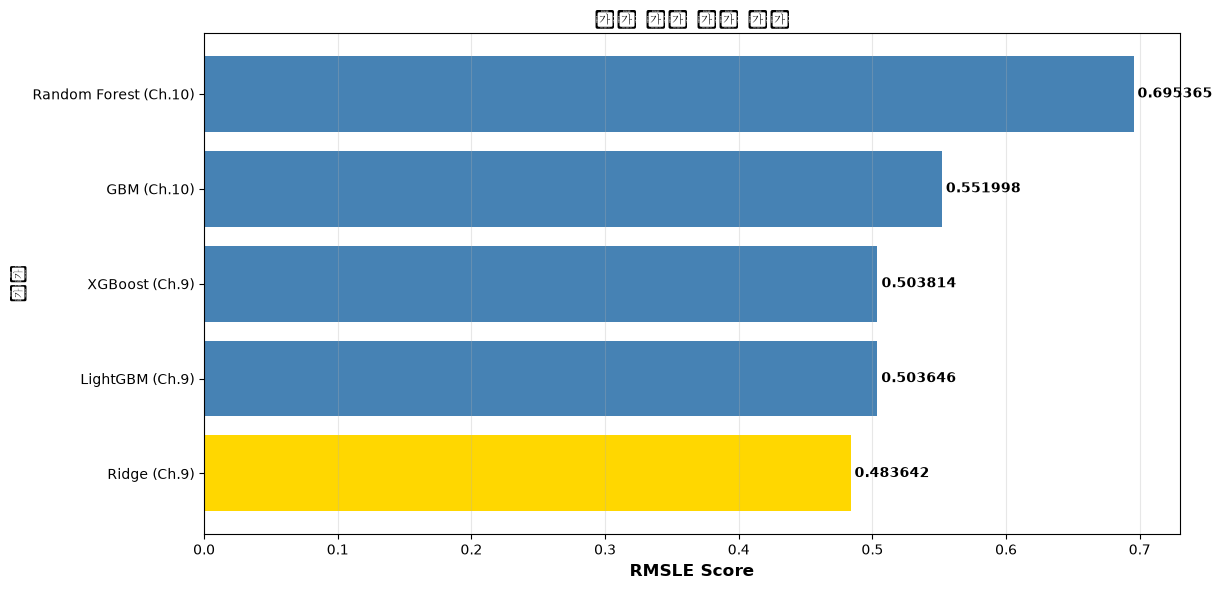

그래프 저장 완료: ../data/processed/model_comparison_fixed.png


In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
bars = plt.barh(results_df['모델'], results_df['RMSLE'], color=colors)

plt.xlabel('RMSLE Score', fontsize=12, fontweight='bold')
plt.ylabel('모델', fontsize=12, fontweight='bold')
plt.title('모든 모델 성능 비교', fontsize=14, fontweight='bold')
plt.tight_layout()

for i, (idx, row) in enumerate(results_df.iterrows()):
    plt.text(row['RMSLE'] + 0.003, i, f"{row['RMSLE']:.6f}", va='center', fontweight='bold')

plt.grid(axis='x', alpha=0.3)
plt.savefig("../data/processed/model_comparison_fixed.png", dpi=300, bbox_inches='tight')
plt.show()

print("그래프 저장 완료: ../data/processed/model_comparison_fixed.png")

## 9단계: 최종 결과 저장

In [11]:
results_df.to_csv("../data/processed/all_models_results_fixed.csv", index=False)
print("전체 모델 결과 저장: ../data/processed/all_models_results_fixed.csv")

summary = f"""
======================================================================
                  Mercari 가격 예측 모델 최종 결과 (수정판)
======================================================================

데이터 처리:
  - 어근추출(Lemmatization): 9장에서 생성한 결과 재사용
  - TF-IDF 벡터화 (9장 결과 재사용, min_df=5 정수 기준)
  - 정형 피처: X_final (유의변수 297개)
  - 훈련/테스트 분할: 80/20

모델 성능 순위 (RMSLE):
"""

for idx, row in results_df.iterrows():
    summary += f"\n  {idx+1}. {row['모델']}: {row['RMSLE']:.6f}"

summary += f"""

최고 성능 모델:
  - 모델명: {best_model_name}
  - RMSLE: {best_rmsle:.6f}

저장된 모델 파일:
  1. Ridge: ridge_lemmatized_model_fixed.pkl
  2. LightGBM: lightgbm_lemmatized_model_fixed.pkl
  3. XGBoost: xgboost_lemmatized_model_fixed.json
  4. GBM (HistGradientBoosting): gbm_lemmatized_model_fixed.pkl
  5. Random Forest: randomforest_lemmatized_model_fixed.pkl

======================================================================
"""

print(summary)

with open("../data/processed/model_summary_fixed.txt", "w", encoding="utf-8") as f:
    f.write(summary)

print("최종 요약 저장: ../data/processed/model_summary_fixed.txt")

전체 모델 결과 저장: ../data/processed/all_models_results_fixed.csv

                  Mercari 가격 예측 모델 최종 결과 (수정판)

데이터 처리:
  - 어근추출(Lemmatization): 9장에서 생성한 결과 재사용
  - TF-IDF 벡터화 (9장 결과 재사용, min_df=5 정수 기준)
  - 정형 피처: X_final (유의변수 297개)
  - 훈련/테스트 분할: 80/20

모델 성능 순위 (RMSLE):

  1. Ridge (Ch.9): 0.483642
  2. LightGBM (Ch.9): 0.503646
  3. XGBoost (Ch.9): 0.503814
  4. GBM (Ch.10): 0.551998
  5. Random Forest (Ch.10): 0.695365

최고 성능 모델:
  - 모델명: Ridge (Ch.9)
  - RMSLE: 0.483642

저장된 모델 파일:
  1. Ridge: ridge_lemmatized_model_fixed.pkl
  2. LightGBM: lightgbm_lemmatized_model_fixed.pkl
  3. XGBoost: xgboost_lemmatized_model_fixed.json
  4. GBM (HistGradientBoosting): gbm_lemmatized_model_fixed.pkl
  5. Random Forest: randomforest_lemmatized_model_fixed.pkl


최종 요약 저장: ../data/processed/model_summary_fixed.txt


In [13]:
print("\n" + "=" * 80)
print("모든 작업 완료!")
print("=" * 80)
print(f"\n총 {len(results_df)}개 모델 비교 완료")
print(f"\n생성된 파일:")
print(f"  1. all_models_results_fixed.csv (전체 모델 결과)")
print(f"  2. model_comparison_fixed.png (성능 비교 그래프)")
print(f"  3. model_summary_fixed.txt (최종 요약)")


모든 작업 완료!

총 5개 모델 비교 완료

생성된 파일:
  1. all_models_results_fixed.csv (전체 모델 결과)
  2. model_comparison_fixed.png (성능 비교 그래프)
  3. model_summary_fixed.txt (최종 요약)
